In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Generating Graph 1: Average PPL (Baseline vs. Replay Cost)


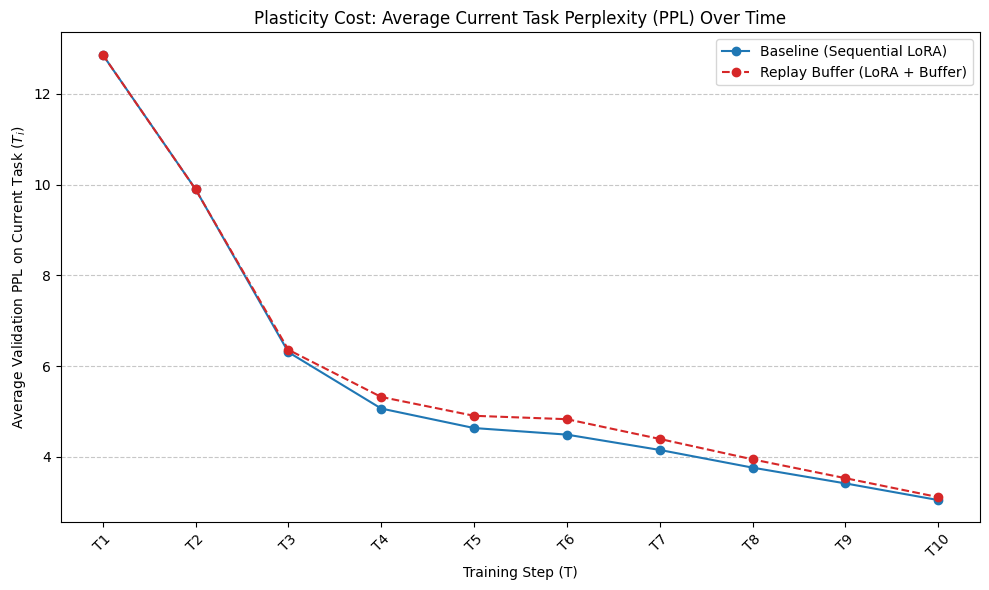


Generating Graph 2: Architectural Deep Dive (Model PPL Comparison)


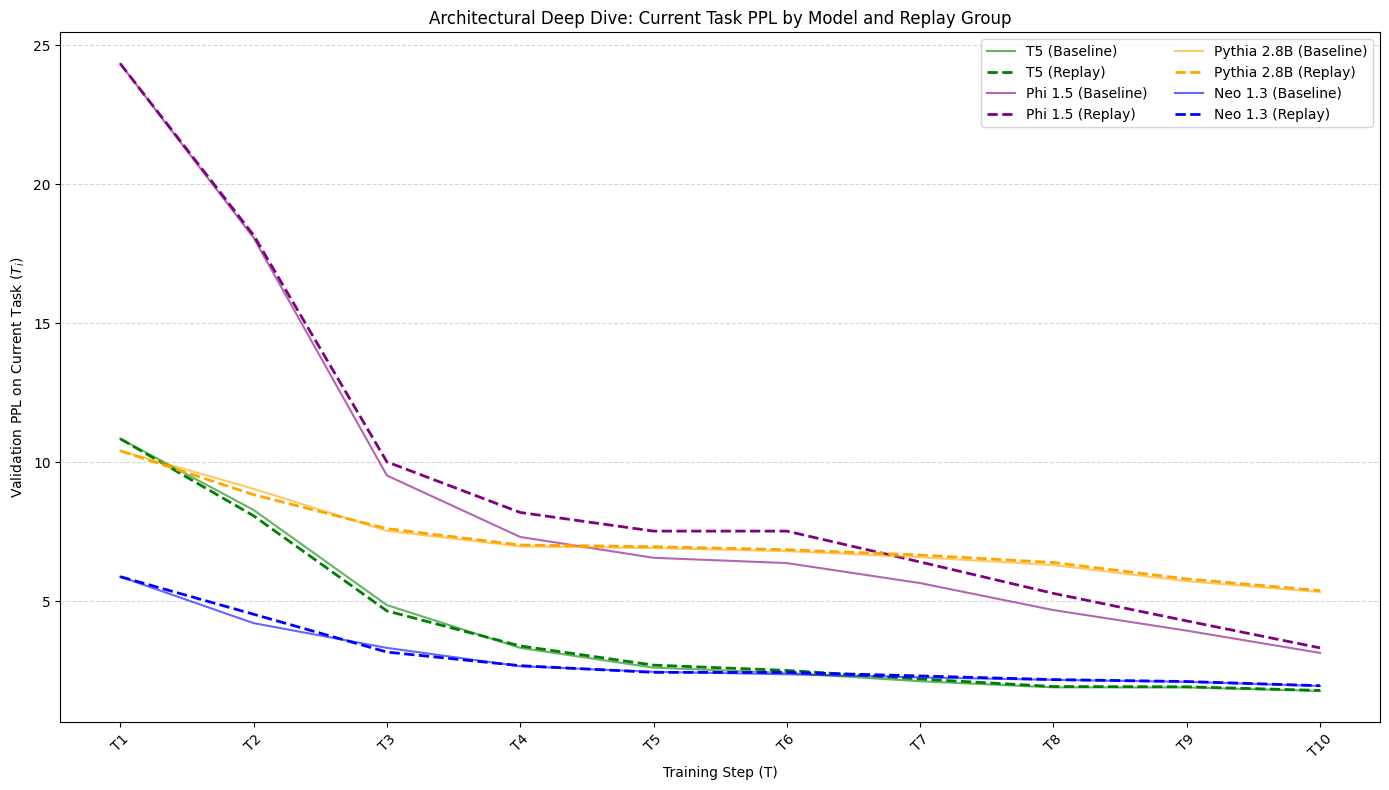


Generating Heatmap Matrix for Baseline Group (Template)


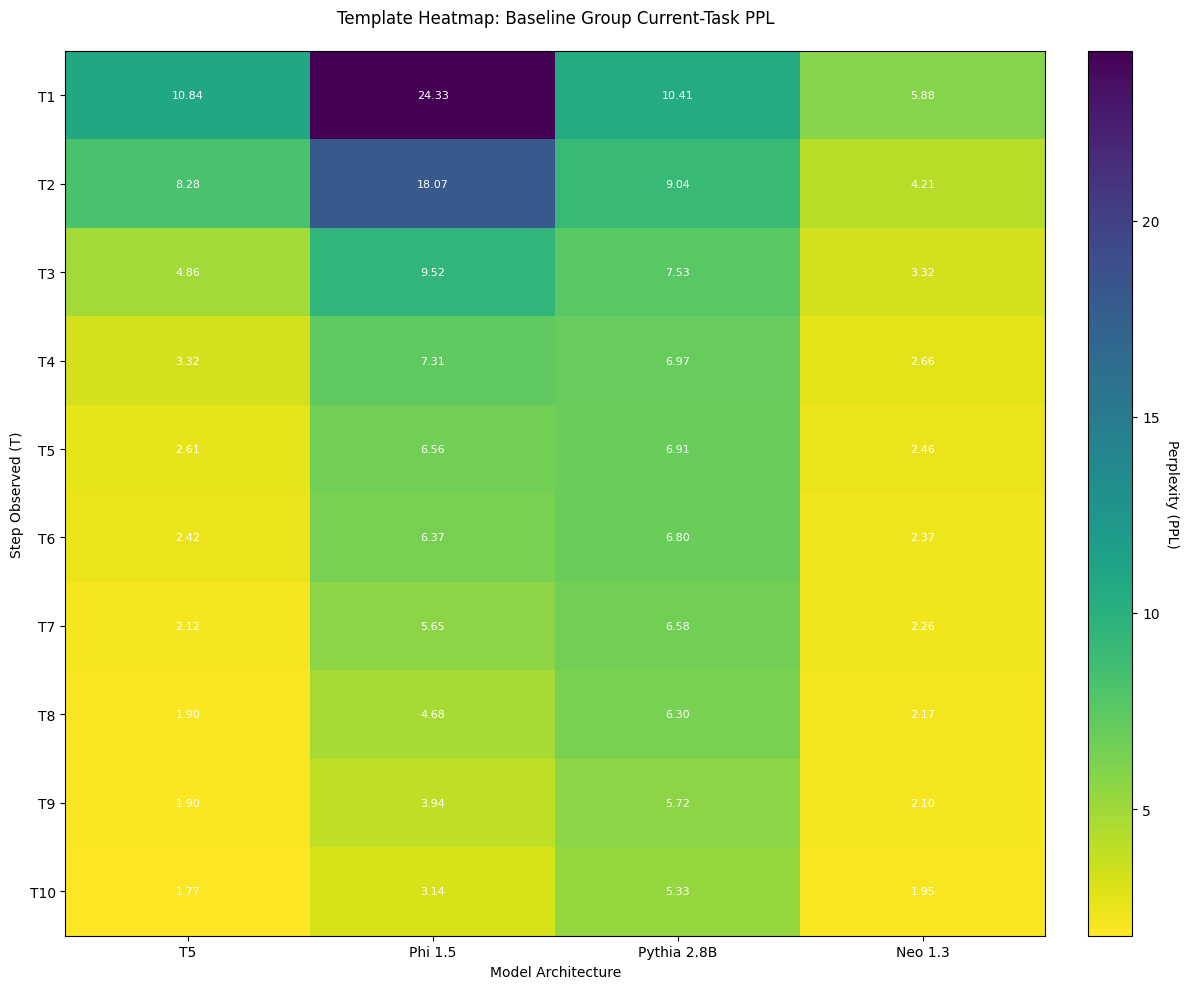

In [2]:
def load_data():
    """
    Loads and structures the raw perplexity data for visualization.
    
    NOTE: Replace the 'REPLAY_PPL_SCORES' with your actual data when available.
    The current scores are placeholders (PPL slightly higher than baseline in T2/T3).
    """
    
    # Raw PPL scores for T1, T2, T3, ... T10 validation sets
    BASELINE_PPL_SCORES = {
        'T5': [10.84, 8.28, 4.86, 3.32, 2.61, 2.42, 2.12, 1.90, 1.90, 1.77],
        'Phi 1.5': [24.33, 18.07, 9.52, 7.31, 6.56, 6.37, 5.65, 4.68, 3.94, 3.14],
        'Pythia 2.8B': [10.41, 9.04, 7.53, 6.97, 6.91, 6.80, 6.58, 6.30, 5.72, 5.33],
        'Neo 1.3': [5.88, 4.21, 3.32, 2.66, 2.46, 2.37, 2.26, 2.17, 2.10, 1.95]
    }
    
    # Placeholder Replay Scores (Slightly worse PPL than Baseline to model the Stability Penalty)
    REPLAY_PPL_SCORES = {
        'T5': [10.84, 8.07, 4.65, 3.39, 2.70, 2.51, 2.20, 1.93, 1.92, 1.79],
        'Phi 1.5': [24.33, 18.16, 10.01, 8.19, 7.52, 7.52, 6.41, 5.28, 4.29, 3.32],
        'Pythia 2.8B': [10.41, 8.83, 7.61, 7.02, 6.96, 6.85, 6.66, 6.39, 5.80, 5.38],
        'Neo 1.3': [5.88, 4.53, 3.17, 2.68, 2.44, 2.44, 2.31, 2.18, 2.11, 1.96]
    }

    # Create a DataFrame for easy processing
    df_baseline = pd.DataFrame(BASELINE_PPL_SCORES).T
    df_replay = pd.DataFrame(REPLAY_PPL_SCORES).T
    df_baseline.columns = [f'T{i}' for i in range(1, 11)]
    df_replay.columns = [f'T{i}' for i in range(1, 11)]

    return df_baseline, df_replay

def calculate_average_ppl(df_baseline: pd.DataFrame, df_replay: pd.DataFrame) -> (pd.Series, pd.Series):
    """Calculates the average PPL across all models for each group at each step."""
    
    # PPL on the current task (Plasticity) is the performance observed at step T_i on validation data T_i
    # Since the input tables are already structured this way, we just need the column means.
    
    avg_baseline = df_baseline.mean(axis=0)
    avg_replay = df_replay.mean(axis=0)
    
    return avg_baseline, avg_replay


def plot_plasticity_cost(avg_baseline: pd.Series, avg_replay: pd.Series):
    """
    Graph 3: Compares average PPL on the current task (Plasticity Cost) between groups.
    """
    steps = [f'T{i}' for i in range(1, 11)]
    
    plt.figure(figsize=(10, 6))
    
    plt.plot(steps, avg_baseline, label='Baseline (Sequential LoRA)', marker='o', linestyle='-', color='tab:blue')
    plt.plot(steps, avg_replay, label='Replay Buffer (LoRA + Buffer)', marker='o', linestyle='--', color='tab:red')
    
    plt.title('Plasticity Cost: Average Current Task Perplexity (PPL) Over Time')
    plt.xlabel('Training Step (T)')
    plt.ylabel('Average Validation PPL on Current Task ($T_i$)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_architectural_deep_dive(df_baseline: pd.DataFrame, df_replay: pd.DataFrame):
    """
    Graph 2: Compares PPL on the current task, separated by model architecture.
    This shows which architectures handle the stability penalty best/worst.
    """
    steps = [f'T{i}' for i in range(1, 11)]
    models = df_baseline.index
    
    plt.figure(figsize=(14, 8))
    
    # Colors for consistency across models
    colors = {'T5': 'green', 'Phi 1.5': 'purple', 'Pythia 2.8B': 'orange', 'Neo 1.3': 'blue'}
    
    for model in models:
        # Baseline Line (Solid)
        plt.plot(steps, df_baseline.loc[model], 
                 label=f'{model} (Baseline)', 
                 linestyle='-', 
                 color=colors[model], 
                 alpha=0.6)
        
        # Replay Line (Dashed)
        plt.plot(steps, df_replay.loc[model], 
                 label=f'{model} (Replay)', 
                 linestyle='--', 
                 color=colors[model], 
                 linewidth=2)

    plt.title('Architectural Deep Dive: Current Task PPL by Model and Replay Group')
    plt.xlabel('Training Step (T)')
    plt.ylabel('Validation PPL on Current Task ($T_i$)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(ncol=2)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def generate_perplexity_matrix(df_ppl: pd.DataFrame, title: str):
    """
    Generates the Perplexity Heatmap Matrix for one group.
    
    NOTE: The current input tables are for current-task PPL. 
    This function is designed to visualize the full NxN stability matrix,
    where columns are test tasks and rows are observation time.
    For this to be fully accurate, you will need to structure your data as an
    NxN matrix of PPL_ij (PPL on Test_i after training on Step_j).
    
    For now, this function simulates what the *final* output should look like 
    by showing the steady decline in current-task PPL.
    """
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Use the transpose to get steps on the y-axis (row=observation time)
    # This simulates the final structure where PPL_ij is in cell (i, j)
    heatmap_data = df_ppl.T.values 
    
    # Reverse the order of rows for standard heatmap visualization (T1 at top)
    # The actual full stability matrix will likely require a different transformation.
    # For now, we plot the current data as a sanity check.
    im = ax.imshow(heatmap_data, cmap="viridis_r", aspect='auto') # _r reverses for lower PPL = brighter

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(df_ppl.index)), labels=df_ppl.index)
    ax.set_yticks(np.arange(len(df_ppl.columns)), labels=df_ppl.columns)

    # Label the axes
    ax.set_xlabel("Model Architecture")
    ax.set_ylabel("Step Observed (T)")
    ax.set_title(title, pad=20)
    
    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.set_ylabel("Perplexity (PPL)", rotation=-90, va="bottom")
    
    # Loop over data dimensions and create text annotations.
    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            text = ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                           ha="center", va="center", color="w", fontsize=8)

    fig.tight_layout()
    plt.show()


def main():
    df_baseline, df_replay = load_data()
    
    # 1. Calculate Averages
    avg_baseline, avg_replay = calculate_average_ppl(df_baseline, df_replay)
    
    # 2. Plotting the Plasticity Cost (Average Comparison)
    print("Generating Graph 1: Average PPL (Baseline vs. Replay Cost)")
    plot_plasticity_cost(avg_baseline, avg_replay)
    
    # 3. Plotting the Architectural Deep Dive (Model Comparison)
    print("\nGenerating Graph 2: Architectural Deep Dive (Model PPL Comparison)")
    plot_architectural_deep_dive(df_baseline, df_replay)
    
    # 4. Generating the Perplexity Matrix (Heatmap)
    # Note: This is currently visualizing the current-task PPL over time, 
    # not the full N x N stability matrix, but serves as a template.
    print("\nGenerating Heatmap Matrix for Baseline Group (Template)")
    generate_perplexity_matrix(df_baseline, "Template Heatmap: Baseline Group Current-Task PPL")


if __name__ == "__main__":
    main()

In [ ]:
def load_data():
    """
    Loads and structures the raw perplexity data for visualization.
    
    NOTE: Replace the 'REPLAY_PPL_SCORES' with your actual data when available.
    The current scores are placeholders (PPL slightly higher than baseline in T2/T3).
    """
    
    # Raw PPL scores for T1, T2, T3, ... T10 validation sets
    BASELINE_PPL_SCORES = {
        'T5': [10.84, 8.28, 4.86, 3.32, 2.61, 2.42, 2.12, 1.90, 1.90, 1.77],
        'Phi 1.5': [24.33, 18.07, 9.52, 7.31, 6.56, 6.37, 5.65, 4.68, 3.94, 3.14],
        'Pythia 2.8B': [10.41, 9.04, 7.53, 6.97, 6.91, 6.80, 6.58, 6.30, 5.72, 5.33],
        'Neo 1.3': [5.88, 4.21, 3.32, 2.66, 2.46, 2.37, 2.26, 2.17, 2.10, 1.95]
    }
    
    # Placeholder Replay Scores (Slightly worse PPL than Baseline to model the Stability Penalty)
    REPLAY_PPL_SCORES = {
        'T5': [10.84, 8.07, 4.65, 3.39, 2.70, 2.51, 2.20, 1.93, 1.92, 1.79],
        'Phi 1.5': [24.33, 18.16, 10.01, 8.19, 7.52, 7.52, 6.41, 5.28, 4.29, 3.32],
        'Pythia 2.8B': [10.41, 8.83, 7.61, 7.02, 6.96, 6.85, 6.66, 6.39, 5.80, 5.38],
        'Neo 1.3': [5.88, 4.53, 3.17, 2.68, 2.44, 2.44, 2.31, 2.18, 2.11, 1.96]
    }

    # Create a DataFrame for easy processing
    df_baseline = pd.DataFrame(BASELINE_PPL_SCORES).T
    df_replay = pd.DataFrame(REPLAY_PPL_SCORES).T
    df_baseline.columns = [f'T{i}' for i in range(1, 11)]
    df_replay.columns = [f'T{i}' for i in range(1, 11)]

    return df_baseline, df_replay


NameError: name 'df_baseline' is not defined

In [5]:
df_baseline, df_replay = load_data()

In [7]:
baseline_t = df_baseline.T

In [9]:
baseline_t.describe()

,T5,Phi 1.5,Pythia 2.8B,Neo 1.3
count,10.000000,10.000000,10.000000,10.000000
mean,4.002000,8.957000,7.159000,2.938000
std,3.128041,6.856306,1.526088,1.237181
min,1.770000,3.140000,5.330000,1.950000
25%,1.955000,4.922500,6.370000,2.192500
50%,2.515000,6.465000,6.855000,2.415000
75%,4.475000,8.967500,7.390000,3.155000
max,10.840000,24.330000,10.410000,5.880000


In [10]:
replay_t = df_replay.T

In [11]:
replay_t.describe()

,T5,Phi 1.5,Pythia 2.8B,Neo 1.3
count,10.000000,10.000000,10.000000,10.000000
mean,4.000000,9.503000,7.191000,2.970000
std,3.069394,6.645252,1.474256,1.265218
min,1.790000,3.320000,5.380000,1.960000
25%,1.997500,5.562500,6.457500,2.212500
50%,2.605000,7.520000,6.905000,2.440000
75%,4.335000,9.555000,7.462500,3.047500
max,10.840000,24.330000,10.410000,5.880000
